In [1]:
# PyTorch - Main deep learning framework
import torch                                    # Core PyTorch library for tensor operations and neural networks
import torch.nn as nn                          # Neural network modules (layers, loss functions, etc.)
import torch.nn.functional as F                # Functional interface for neural network operations (activations, etc.)
import torch.optim as optim                    # Optimization algorithms (SGD, Adam, etc.)

# PyTorch Vision - Computer vision utilities
import torchvision                              # PyTorch's computer vision library (datasets, models, transforms)
import torchvision.transforms as transforms     # Image preprocessing and augmentation transforms

# Data handling utilities
from torch.utils.data import DataLoader         # Efficiently loads data in batches for training
from torch.utils.data import random_split       # Randomly splits dataset into train/validation sets

# Visualization libraries
import matplotlib.pyplot as plt                 # Primary plotting library for displaying images and graphs
import numpy as np                              # Numerical computing library for array operations

# Machine learning evaluation metrics
from sklearn.metrics import classification_report  # Generates precision, recall, f1-score for each class
from sklearn.metrics import confusion_matrix       # Creates confusion matrix for evaluating predictions

# Advanced visualization
import seaborn as sns                            # Statistical data visualization (better heatmaps for confusion matrix)

# Image handling
from PIL import Image                            # Python Imaging Library for loading/saving images

# Python standard libraries
import random                                    # For random sampling and seeding
import os                                        # For file/directory operations

In [2]:
# Check if GPU is available, else use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
# For Colab, this will typically show 'cuda' if you've enabled GPU runtime

Using device: cuda


In [5]:
#  DEFINE HYPERPARAMETERS
BATCH_SIZE = 64          # Number of samples per batch
LEARNING_RATE = 0.001    # Learning rate for optimizer
EPOCHS = 5            # Number of training epochs (increase for better accuracy)
VALIDATION_SPLIT = 0.2   # 20% of training data used for validation
NUM_CLASSES = 10         # CIFAR-10 has 10 classes
INPUT_CHANNELS = 3       # RGB images have 3 channels

In [6]:
# Step 4 & 5: Preprocessing and Normalization
# Transform for training data (includes data augmentation)
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),           # Resize to match AlexNet/VGG input size
    transforms.RandomHorizontalFlip(),        # Random horizontal flip for augmentation
    transforms.RandomRotation(10),            # Random rotation up to 10 degrees
    transforms.ColorJitter(brightness=0.2,    # Random brightness adjustment
                          contrast=0.2,       # Random contrast adjustment
                          saturation=0.2,     # Random saturation adjustment
                          hue=0.1),           # Random hue adjustment
    transforms.ToTensor(),                    # Convert PIL Image to tensor (0-255 to 0-1)
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Normalize with ImageNet stats
                        std=[0.229, 0.224, 0.225])     # Standard deviation for each channel
])

In [7]:
# LOAD AND SPLIT DATASET (Steps 1 & 2: Data Loading and Validation)
# Load CIFAR-10 training dataset
full_train_dataset = torchvision.datasets.CIFAR10(
    root='./data',            # Directory to store/download dataset
    train=True,               # Load training set
    download=True,            # Download if not present
    transform=transform_train # Apply training transformations
)

100%|██████████| 170M/170M [00:03<00:00, 42.8MB/s]


In [9]:
full_train_dataset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
               ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.1, 0.1))
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [10]:
 # These are the 10 classes in CIFAR-10 dataset
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print("CIFAR-10 Classes:", classes)
print("Total number of classes:", len(classes))

CIFAR-10 Classes: ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
Total number of classes: 10


In [11]:
# STEP 2: Then get the image and label
image, label = full_train_dataset[0]

In [12]:
# Print basic information about the image tensor
print("SINGLE IMAGE INFORMATION")
print("="*60)
print(f"Image tensor shape: {image.shape}")  # Should be (3, 224, 224)
print(f"Image tensor min value: {image.min():.3f}")  # Normalized min value
print(f"Image tensor max value: {image.max():.3f}")  # Normalized max value
print(f"Label index: {label}")  # Numeric label (0-9)
print(f"Label name: {classes[label]}")  # Class name - NOW IT WILL WORK!
print(f"Data type: {image.dtype}")  # Usually torch.float32
print(f"Device: {image.device}")  # Usually CPU
print("="*60)

SINGLE IMAGE INFORMATION
Image tensor shape: torch.Size([3, 224, 224])
Image tensor min value: -2.118
Image tensor max value: 2.640
Label index: 6
Label name: frog
Data type: torch.float32
Device: cpu


In [13]:
# VISUALIZE THE IMAGE (WITH DENORMALIZATION)

# Clone to avoid modifying original tensor
img_display = image.clone()

# Denormalize: Reverse the normalization
# Formula: pixel = (normalized_pixel * std) + mean
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)  # Reshape to (3,1,1) for broadcasting
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)   # Reshape to (3,1,1) for broadcasting
img_display = img_display * std + mean  # Apply denormalization
img_display = torch.clamp(img_display, 0, 1)  # Clamp values to [0,1] range

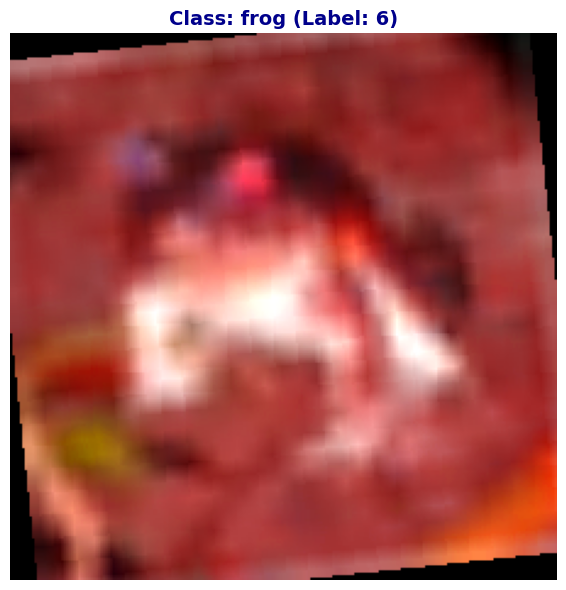

In [14]:
# Convert tensor to numpy for matplotlib
# PyTorch format: (C, H, W) -> NumPy format needed: (H, W, C)
img_numpy = img_display.numpy()  # Convert to numpy array
img_numpy = np.transpose(img_numpy, (1, 2, 0))  # Transpose dimensions

# Display the image using matplotlib
plt.figure(figsize=(6, 6))
plt.imshow(img_numpy)  # Display the image
plt.title(f"Class: {classes[label]} (Label: {label})",
          fontsize=14, fontweight='bold', color='darkblue')
plt.axis('off')  # Remove axis
plt.tight_layout()
plt.show()

FIRST 5 IMAGES IN DATASET
Image 0: Index=0, Label=6, Class='frog'
Image 1: Index=1, Label=9, Class='truck'
Image 2: Index=2, Label=9, Class='truck'
Image 3: Index=3, Label=4, Class='deer'
Image 4: Index=4, Label=1, Class='automobile'


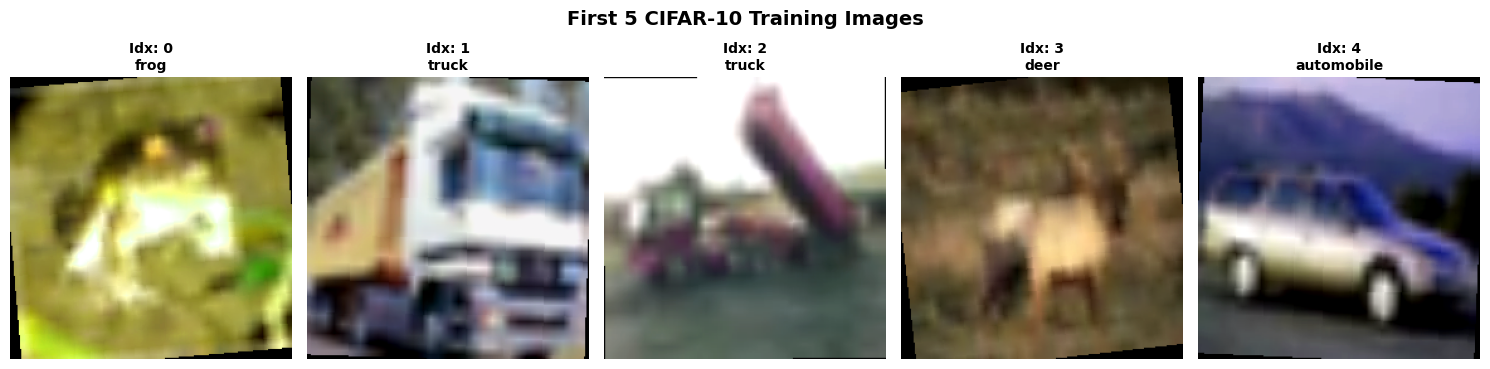

In [17]:
print("FIRST 5 IMAGES IN DATASET")

fig, axes = plt.subplots(1, 5, figsize=(15, 4))  # Create 5 subplots in a row

for i in range(5):
    # Get image and label
    image, label = full_train_dataset[i]

    # Denormalize
    img = image.clone()
    img = img * std + mean
    img = torch.clamp(img, 0, 1)

    # Convert and display
    img_np = np.transpose(img.numpy(), (1, 2, 0))
    axes[i].imshow(img_np)
    axes[i].set_title(f"Idx: {i}\n{classes[label]}", fontsize=10, fontweight='bold')
    axes[i].axis('off')

    # Print info
    print(f"Image {i}: Index={i}, Label={label}, Class='{classes[label]}'")

plt.suptitle("First 5 CIFAR-10 Training Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# Transform for validation/test data (no augmentation, only normalization)
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),           # Resize to match network input size
    transforms.ToTensor(),                    # Convert PIL Image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Same normalization as training
                        std=[0.229, 0.224, 0.225])
])

In [19]:
# Calculate sizes for train-validation split
train_size = int((1 - VALIDATION_SPLIT) * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
print(f"Training samples: {train_size}")
print(f"Validation samples: {val_size}")

Training samples: 40000
Validation samples: 10000


In [20]:
# Split dataset into training and validation sets
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # Set seed for reproducibility
)

In [22]:
# Load CIFAR-10 test dataset
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',            # Same directory as training data
    train=False,              # Load test set
    download=True,            # Download if not present
    transform=transform_test  # Apply test transformations
)
print(f"Test samples: {len(test_dataset)}")

Test samples: 10000


In [23]:
# CREATE DATA LOADERS
# DataLoader for training data (with shuffling)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,        # Shuffle training data for better learning
    num_workers=2,       # Number of subprocesses for data loading
    pin_memory=True      # Pin memory for faster GPU transfer
)

In [24]:
# DataLoader for validation data (no shuffling needed)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,       # No need to shuffle validation data
    num_workers=2,
    pin_memory=True
)

In [25]:
# DataLoader for test data (no shuffling needed)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,       # No need to shuffle test data
    num_workers=2,
    pin_memory=True
)

In [26]:
# Input image specifications
input_channels = 3        # RGB image has 3 color channels (Red, Green, Blue)
input_height = 224        # Input image height in pixels
input_width = 224         # Input image width in pixels
batch_size = 1            # Number of images processed together
num_classes = 10          # CIFAR-10 has 10 categories to classify

In [27]:
# Print input specifications
print(f"\nInput Specifications:")
print(f"  Channels: {input_channels} (RGB)")
print(f"  Image Size: {input_height}x{input_width}")
print(f"  Batch Size: {batch_size}")
print(f"  Number of Classes: {num_classes}")


Input Specifications:
  Channels: 3 (RGB)
  Image Size: 224x224
  Batch Size: 1
  Number of Classes: 10


In [28]:
# --- CONVOLUTIONAL LAYER 1 ---
print("\n--- Convolutional Layer 1 ---")
print("Purpose: Detect basic features like edges, corners, colors")
conv1 = nn.Conv2d(
    in_channels=3,          # Takes RGB input (3 channels)
    out_channels=96,        # Creates 96 feature maps (96 different filters)
    kernel_size=11,         # Each filter is 11x11 pixels (large filter to capture broad features)
    stride=4,               # Filter moves 4 pixels at a time (reduces spatial size quickly)
    padding=2               # Adds 2 pixels border of zeros around input
)


--- Convolutional Layer 1 ---
Purpose: Detect basic features like edges, corners, colors


In [29]:
# Mathematical calculation for output size:
# Output_Size = ((Input_Size - Kernel_Size + 2*Padding) / Stride) + 1
# = ((224 - 11 + 2*2) / 4) + 1 = (224 - 11 + 4) / 4 + 1 = 217/4 + 1 = 54.25 + 1 = 55.25 → floor to 55
print(f"  Input shape:  ({batch_size}, {input_channels}, {input_height}, {input_width})")
print(f"  Output shape: ({batch_size}, 96, 55, 55)")
print(f"  Parameters:   96 filters × (3 × 11 × 11) = {96 * 3 * 11 * 11:,} weights + 96 biases")

  Input shape:  (1, 3, 224, 224)
  Output shape: (1, 96, 55, 55)
  Parameters:   96 filters × (3 × 11 × 11) = 34,848 weights + 96 biases


In [30]:
# Weight initialization for Conv1
nn.init.kaiming_normal_(conv1.weight, mode='fan_out', nonlinearity='relu')
# Kaiming/He initialization: weights are set to small random values
# This prevents vanishing/exploding gradients in deep networks
# 'fan_out' mode preserves the variance of outputs
print(f"  Weights initialized with Kaiming Normal (He initialization)")

  Weights initialized with Kaiming Normal (He initialization)


In [31]:
# --- BATCH NORMALIZATION 1 ---
print("\n--- Batch Normalization 1 ---")
print("Purpose: Normalize the output of Conv1 to stabilize training")
bn1 = nn.BatchNorm2d(96)  # Normalizes across 96 feature maps
# BatchNorm calculates mean and variance for each feature map
# Then normalizes: output = (input - mean) / sqrt(variance + epsilon)
# Learnable parameters: gamma (scale) and beta (shift)
print(f"  Normalizes 96 feature maps")
print(f"  Parameters: 96 gamma + 96 beta = 192 learnable parameters")


--- Batch Normalization 1 ---
Purpose: Normalize the output of Conv1 to stabilize training
  Normalizes 96 feature maps
  Parameters: 96 gamma + 96 beta = 192 learnable parameters


In [32]:
# --- ACTIVATION FUNCTION (ReLU) ---
print("\n--- ReLU Activation (After Conv1) ---")
print("Purpose: Introduce non-linearity, allows network to learn complex patterns")
# ReLU(x) = max(0, x) - Sets all negative values to 0
# Benefits: Fast computation, reduces vanishing gradient problem
print(f"  Function: ReLU(x) = max(0, x)")
print(f"  Output shape unchanged: ({batch_size}, 96, 55, 55)")


--- ReLU Activation (After Conv1) ---
Purpose: Introduce non-linearity, allows network to learn complex patterns
  Function: ReLU(x) = max(0, x)
  Output shape unchanged: (1, 96, 55, 55)


In [33]:
# --- MAX POOLING LAYER 1 ---
print("\n--- Max Pooling Layer 1 ---")
print("Purpose: Reduce spatial dimensions, retain most important features")
pool1 = nn.MaxPool2d(
    kernel_size=3,          # Pooling window is 3x3
    stride=2                # Window moves 2 pixels at a time
)
# Output size calculation:
# Output = ((55 - 3) / 2) + 1 = 52/2 + 1 = 27
print(f"  Input shape:  ({batch_size}, 96, 55, 55)")
print(f"  Output shape: ({batch_size}, 96, 27, 27)")
print(f"  Operation: Takes maximum value from each 3x3 window")


--- Max Pooling Layer 1 ---
Purpose: Reduce spatial dimensions, retain most important features
  Input shape:  (1, 96, 55, 55)
  Output shape: (1, 96, 27, 27)
  Operation: Takes maximum value from each 3x3 window


In [34]:
# --- CONVOLUTIONAL LAYER 2 ---
print("\n--- Convolutional Layer 2 ---")
print("Purpose: Detect more complex patterns by combining basic features")
conv2 = nn.Conv2d(
    in_channels=96,         # Takes 96 feature maps from previous layer
    out_channels=256,       # Creates 256 feature maps (more complex patterns)
    kernel_size=5,          # 5x5 kernel (smaller, captures mid-level features)
    stride=1,               # Moves 1 pixel at a time (finer scanning)
    padding=2               # Same padding (maintains spatial dimensions)
)
# Output size: ((27 - 5 + 2*2) / 1) + 1 = (27 - 5 + 4) + 1 = 27
print(f"  Input shape:  ({batch_size}, 96, 27, 27)")
print(f"  Output shape: ({batch_size}, 256, 27, 27)")
print(f"  Parameters:   256 filters × (96 × 5 × 5) = {256 * 96 * 5 * 5:,} weights + 256 biases")
print(f"  Note: 'Same' padding keeps spatial dimensions unchanged")

# Weight initialization
nn.init.kaiming_normal_(conv2.weight, mode='fan_out', nonlinearity='relu')
print(f"  Weights initialized with Kaiming Normal")

# --- BATCH NORMALIZATION 2 ---
print("\n--- Batch Normalization 2 ---")
bn2 = nn.BatchNorm2d(256)  # Normalizes across 256 feature maps
print(f"  Normalizes 256 feature maps")
print(f"  Parameters: 256 gamma + 256 beta = 512 learnable parameters")

# --- MAX POOLING LAYER 2 ---
print("\n--- Max Pooling Layer 2 ---")
pool2 = nn.MaxPool2d(kernel_size=3, stride=2)
# Output size: ((27 - 3) / 2) + 1 = 24/2 + 1 = 13
print(f"  Input shape:  ({batch_size}, 256, 27, 27)")
print(f"  Output shape: ({batch_size}, 256, 13, 13)")


--- Convolutional Layer 2 ---
Purpose: Detect more complex patterns by combining basic features
  Input shape:  (1, 96, 27, 27)
  Output shape: (1, 256, 27, 27)
  Parameters:   256 filters × (96 × 5 × 5) = 614,400 weights + 256 biases
  Note: 'Same' padding keeps spatial dimensions unchanged
  Weights initialized with Kaiming Normal

--- Batch Normalization 2 ---
  Normalizes 256 feature maps
  Parameters: 256 gamma + 256 beta = 512 learnable parameters

--- Max Pooling Layer 2 ---
  Input shape:  (1, 256, 27, 27)
  Output shape: (1, 256, 13, 13)


In [35]:
# --- CONVOLUTIONAL LAYER 3 ---
print("\n--- Convolutional Layer 3 ---")
print("Purpose: Learn high-level features and object parts")
conv3 = nn.Conv2d(
    in_channels=256,        # Takes 256 feature maps
    out_channels=384,       # Creates 384 feature maps (richer feature representation)
    kernel_size=3,          # 3x3 kernel (small, captures detailed features)
    stride=1,               # Fine scanning
    padding=1               # Same padding
)
# Output size: ((13 - 3 + 2) / 1) + 1 = 13
print(f"  Input shape:  ({batch_size}, 256, 13, 13)")
print(f"  Output shape: ({batch_size}, 384, 13, 13)")
print(f"  Parameters:   384 filters × (256 × 3 × 3) = {384 * 256 * 3 * 3:,} weights + 384 biases")
nn.init.kaiming_normal_(conv3.weight, mode='fan_out', nonlinearity='relu')
print(f"  Weights initialized with Kaiming Normal")

# --- BATCH NORMALIZATION 3 ---
print("\n--- Batch Normalization 3 ---")
bn3 = nn.BatchNorm2d(384)
print(f"  Normalizes 384 feature maps")
print(f"  Parameters: 384 gamma + 384 beta = 768 learnable parameters")




--- Convolutional Layer 3 ---
Purpose: Learn high-level features and object parts
  Input shape:  (1, 256, 13, 13)
  Output shape: (1, 384, 13, 13)
  Parameters:   384 filters × (256 × 3 × 3) = 884,736 weights + 384 biases
  Weights initialized with Kaiming Normal

--- Batch Normalization 3 ---
  Normalizes 384 feature maps
  Parameters: 384 gamma + 384 beta = 768 learnable parameters


In [36]:
# --- CONVOLUTIONAL LAYER 4 ---
print("\n--- Convolutional Layer 4 ---")
print("Purpose: Further refine high-level feature detection")
conv4 = nn.Conv2d(
    in_channels=384,        # Takes 384 feature maps
    out_channels=384,       # Maintains 384 feature maps (deepens feature quality)
    kernel_size=3,          # 3x3 kernel
    stride=1,               # Fine scanning
    padding=1               # Same padding
)
# Output size: ((13 - 3 + 2) / 1) + 1 = 13
print(f"  Input shape:  ({batch_size}, 384, 13, 13)")
print(f"  Output shape: ({batch_size}, 384, 13, 13)")
print(f"  Parameters:   384 filters × (384 × 3 × 3) = {384 * 384 * 3 * 3:,} weights + 384 biases")
nn.init.kaiming_normal_(conv4.weight, mode='fan_out', nonlinearity='relu')
print(f"  Weights initialized with Kaiming Normal")


# --- BATCH NORMALIZATION 4 ---
print("\n--- Batch Normalization 4 ---")
bn4 = nn.BatchNorm2d(384)
print(f"  Normalizes 384 feature maps")
print(f"  Parameters: 384 gamma + 384 beta = 768 learnable parameters")


--- Convolutional Layer 4 ---
Purpose: Further refine high-level feature detection
  Input shape:  (1, 384, 13, 13)
  Output shape: (1, 384, 13, 13)
  Parameters:   384 filters × (384 × 3 × 3) = 1,327,104 weights + 384 biases
  Weights initialized with Kaiming Normal

--- Batch Normalization 4 ---
  Normalizes 384 feature maps
  Parameters: 384 gamma + 384 beta = 768 learnable parameters


In [37]:
# --- CONVOLUTIONAL LAYER 5 ---
print("\n--- Convolutional Layer 5 ---")
print("Purpose: Final convolutional layer for highest-level features")
conv5 = nn.Conv2d(
    in_channels=384,        # Takes 384 feature maps
    out_channels=256,       # Reduces to 256 feature maps (compression)
    kernel_size=3,          # 3x3 kernel
    stride=1,               # Fine scanning
    padding=1               # Same padding
)
# Output size: ((13 - 3 + 2) / 1) + 1 = 13
print(f"  Input shape:  ({batch_size}, 384, 13, 13)")
print(f"  Output shape: ({batch_size}, 256, 13, 13)")
print(f"  Parameters:   256 filters × (384 × 3 × 3) = {256 * 384 * 3 * 3:,} weights + 256 biases")
nn.init.kaiming_normal_(conv5.weight, mode='fan_out', nonlinearity='relu')
print(f"  Weights initialized with Kaiming Normal")

# --- BATCH NORMALIZATION 5 ---
print("\n--- Batch Normalization 5 ---")
bn5 = nn.BatchNorm2d(256)
print(f"  Normalizes 256 feature maps")
print(f"  Parameters: 256 gamma + 256 beta = 512 learnable parameters")

# --- MAX POOLING LAYER 3 ---
print("\n--- Max Pooling Layer 3 ---")
print("Purpose: Final spatial reduction before classification")
pool3 = nn.MaxPool2d(kernel_size=3, stride=2)
# Output size: ((13 - 3) / 2) + 1 = 10/2 + 1 = 6
print(f"  Input shape:  ({batch_size}, 256, 13, 13)")
print(f"  Output shape: ({batch_size}, 256, 6, 6)")
print(f"  Note: This 6x6x256 output will be flattened for FC layers")


--- Convolutional Layer 5 ---
Purpose: Final convolutional layer for highest-level features
  Input shape:  (1, 384, 13, 13)
  Output shape: (1, 256, 13, 13)
  Parameters:   256 filters × (384 × 3 × 3) = 884,736 weights + 256 biases
  Weights initialized with Kaiming Normal

--- Batch Normalization 5 ---
  Normalizes 256 feature maps
  Parameters: 256 gamma + 256 beta = 512 learnable parameters

--- Max Pooling Layer 3 ---
Purpose: Final spatial reduction before classification
  Input shape:  (1, 256, 13, 13)
  Output shape: (1, 256, 6, 6)
  Note: This 6x6x256 output will be flattened for FC layers


In [38]:
# Calculate flattened size
flattened_size = 256 * 6 * 6  # After conv5+pool3: 256 channels × 6×6 spatial = 9216
print(f"\nFlattened feature size: {flattened_size} (256 × 6 × 6)")



Flattened feature size: 9216 (256 × 6 × 6)


In [39]:
print("\n--- Dropout Layers ---")
print("Purpose: Prevent overfitting by randomly deactivating neurons during training")
dropout1 = nn.Dropout(p=0.5)  # 50% probability of dropping a neuron
dropout2 = nn.Dropout(p=0.5)  # 50% probability for second dropout
# During training: randomly sets 50% of inputs to 0
# During testing: all neurons are used, but outputs are scaled
print(f"  Dropout Rate: 50% (p=0.5)")
print(f"  During training: Randomly drops 50% of neurons")
print(f"  During inference: All neurons active, outputs scaled by 0.5")


--- Dropout Layers ---
Purpose: Prevent overfitting by randomly deactivating neurons during training
  Dropout Rate: 50% (p=0.5)
  During training: Randomly drops 50% of neurons
  During inference: All neurons active, outputs scaled by 0.5


In [40]:
# --- FULLY CONNECTED LAYER 1 ---
print("\n--- Fully Connected Layer 1 (FC1) ---")
print("Purpose: First dense layer for high-level reasoning")
fc1 = nn.Linear(
    in_features=256 * 6 * 6,   # Takes flattened features (9216 values)
    out_features=4096           # Outputs 4096 values (high-dimensional representation)
)
nn.init.kaiming_normal_(fc1.weight, mode='fan_out', nonlinearity='relu')
print(f"  Input features:  9,216 (flattened conv output)")
print(f"  Output features: 4,096")
print(f"  Parameters:      9,216 × 4,096 = {9216 * 4096:,} weights + 4,096 biases")
print(f"  Weights initialized with Kaiming Normal")


--- Fully Connected Layer 1 (FC1) ---
Purpose: First dense layer for high-level reasoning
  Input features:  9,216 (flattened conv output)
  Output features: 4,096
  Parameters:      9,216 × 4,096 = 37,748,736 weights + 4,096 biases
  Weights initialized with Kaiming Normal


In [41]:
# --- BATCH NORMALIZATION FC1 ---
print("\n--- Batch Normalization for FC1 ---")
bn_fc1 = nn.BatchNorm1d(4096)  # Normalizes 4096 values
# BatchNorm1d is used for fully connected layers (1D tensor)
# vs BatchNorm2d used for conv layers (2D tensor)
print(f"  Normalizes 4,096 values")
print(f"  Parameters: 4,096 gamma + 4,096 beta = 8,192 learnable parameters")


--- Batch Normalization for FC1 ---
  Normalizes 4,096 values
  Parameters: 4,096 gamma + 4,096 beta = 8,192 learnable parameters


In [42]:
# --- FULLY CONNECTED LAYER 2 ---
print("\n--- Fully Connected Layer 2 (FC2) ---")
print("Purpose: Second dense layer for combining learned features")
fc2 = nn.Linear(
    in_features=4096,          # Takes 4096 values from FC1
    out_features=4096           # Outputs 4096 values (same size, deep reasoning)
)
nn.init.kaiming_normal_(fc2.weight, mode='fan_out', nonlinearity='relu')
print(f"  Input features:  4,096")
print(f"  Output features: 4,096")
print(f"  Parameters:      4,096 × 4,096 = {4096 * 4096:,} weights + 4,096 biases")
print(f"  Weights initialized with Kaiming Normal")

# --- BATCH NORMALIZATION FC2 ---
print("\n--- Batch Normalization for FC2 ---")
bn_fc2 = nn.BatchNorm1d(4096)
print(f"  Normalizes 4,096 values")
print(f"  Parameters: 4,096 gamma + 4,096 beta = 8,192 learnable parameters")


--- Fully Connected Layer 2 (FC2) ---
Purpose: Second dense layer for combining learned features
  Input features:  4,096
  Output features: 4,096
  Parameters:      4,096 × 4,096 = 16,777,216 weights + 4,096 biases
  Weights initialized with Kaiming Normal

--- Batch Normalization for FC2 ---
  Normalizes 4,096 values
  Parameters: 4,096 gamma + 4,096 beta = 8,192 learnable parameters


In [43]:
# --- OUTPUT LAYER (Fully Connected Layer 3) ---
print("\n--- Output Layer (FC3 - Final Classification) ---")
print("Purpose: Produce final class scores")
fc3 = nn.Linear(
    in_features=4096,          # Takes 4096 values from FC2
    out_features=num_classes    # Outputs 10 values (one score per class)
)
nn.init.xavier_normal_(fc3.weight)  # Xavier/Glorot initialization for output layer
# Xavier initialization is good for layers without ReLU (like final layer)
# It keeps variance consistent across layers
print(f"  Input features:  4,096")
print(f"  Output features: {num_classes} (one per class)")
print(f"  Parameters:      4,096 × {num_classes} = {4096 * num_classes:,} weights + {num_classes} biases")
print(f"  Weights initialized with Xavier Normal")
print(f"  Note: NO activation function on output (raw scores/logits)")



--- Output Layer (FC3 - Final Classification) ---
Purpose: Produce final class scores
  Input features:  4,096
  Output features: 10 (one per class)
  Parameters:      4,096 × 10 = 40,960 weights + 10 biases
  Weights initialized with Xavier Normal
  Note: NO activation function on output (raw scores/logits)
